# Criteo CTR — Simple End-to-End Notebook

The dataset is Criteo click-through-rate (CTR) data: 1M rows, a binary `target` (1 = click, 0 = no click), 13 numeric features (`intCol_*`) and 26 hashed categorical features (`catCol_*`).

### Guiding philosophy: we have no intuition, so we test everything

The columns are **hashed and anonymized** — `e5ba7672` could be a country code, an ad slot, a browser fingerprint, anything. We can't reason about what each feature *means*, so we can't reason about what preprocessing *should* work.

The only honest approach is to **try multiple alternatives at every decision point and let the validation set decide**:

| Decision | What we'll try |
|---|---|
| Which model? | LR, NB, KNN, GBM (section 5) |
| How to fix imbalance? | None / ROS / RUS / SMOTE / SMOTETomek (section 7) |
| What probability cutoff? | sweep 0.10 → 0.90 (section 8) |
| Which categorical encoder? | Ordinal / Frequency / Target / Hybrid (section 10) |
| Which scaling method? | None / Standard / MinMax / Robust / MaxAbs (section 11) |
| Which imputation? | Median / Mean / Constant 0 / Constant -1 / KNN (section 12) |
| How to handle outliers? | None / 1-99 clip / 5-95 clip / log1p / log+clip (section 13) |
| Which GBM hyperparams? | small / default / beefy / very-beefy (section 14) |

The plan in order:

1. **EDA** — get a feel for the data before touching it.
2. **Cleansing + encoding + scaling** — wrap it all in one sklearn pipeline so we don't leak from val/test into train. (This is our v1 — we'll replace pieces of it later.)
3. **Feature importance** — see what the model actually uses.
4. **Stratified train/val/test split** — train to fit, val to compare, test for the final number.
5. **Compare a few simple models** on val.
6. **Final evaluation** on the held-out test set.
7. **Class imbalance** — recall came out low, so try resampling.
8. **Threshold tuning** — the easiest win of all.
9. **Improved preprocessor** — TargetEncoder + missing indicators + bigger GBM.
10. **Encoder shootout** — try several encoders and pick the winner on val.
11. **Scaling shootout** — try several scalers (and see why GBM doesn't care, but LR does).
12. **Imputation shootout** — try several imputation strategies.
13. **Outlier handling shootout** — try several ways of taming the long tails.
14. **GBM hyperparameter sweep** — try a few different model sizes.

In [ ]:

# GET THE DATA HERE: https://www.kaggle.com/datasets/datuman/criteo-ad-click-limited-1m
#https://www.kaggle.com/datasets/datuman/criteo-ad-click-limited-1m
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Criteo_1M_with_nans.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000000, 40)


,target,intCol_0,intCol_1,intCol_2,intCol_3,intCol_4,intCol_5,intCol_6,intCol_7,intCol_8,...,catCol_16,catCol_17,catCol_18,catCol_19,catCol_20,catCol_21,catCol_22,catCol_23,catCol_24,catCol_25
0,0,1.0,1,5.0,0.0,1382.0,4.0,15.0,2.0,181.0,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,NaN,3a171ecb,c5c50484,e8b83407,9727dd16
1,0,2.0,0,44.0,1.0,102.0,8.0,2.0,2.0,4.0,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
2,0,2.0,0,1.0,14.0,767.0,89.0,4.0,2.0,245.0,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
3,0,NaN,893,NaN,NaN,4392.0,NaN,0.0,0.0,0.0,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
4,0,3.0,-1,NaN,0.0,2.0,0.0,3.0,0.0,0.0,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN


In [18]:
# Split the column names into numeric vs categorical groups.
# Why: every preprocessing step (imputation, scaling, encoding) has to be applied
# to the right *kind* of column, so we keep the two groups separate from the start.
int_cols = [c for c in df.columns if c.startswith('intCol')]
cat_cols = [c for c in df.columns if c.startswith('catCol')]

# Separate features (X) from the label (y).
# Why: sklearn's API expects them apart — and it prevents us from accidentally
# using the target as a feature later on.
X = df.drop(columns=['target'])
y = df['target']

# Quick sanity print: how many of each, and the positive-class rate.
# Why: knowing the positive rate up front tells us whether the data is imbalanced
# (here ~25% positive — imbalanced enough that "always predict 0" already wins on accuracy).
n_num = len(int_cols)
n_cat = len(cat_cols)
positive_rate = y.mean()
print(f'{n_num} numeric, {n_cat} categorical, target: {positive_rate:.3f} positive rate')

13 numeric, 26 categorical, target: 0.255 positive rate


## 1. EDA

Before doing anything I want a feel for the data. The questions in my head:

- How big is it and what types of columns are there? → `df.info()`, `df.describe()`
- Is the target balanced? → if it's heavily skewed I'll need to handle that later
- How bad are the missing values? → tells me how aggressive my imputation needs to be
- What do the numeric distributions look like? → if they're skewed I'll want a `log1p` or capping
- How many unique values per categorical column? → decides which encoding I can use (one-hot only works for low cardinality)
- Anything obviously correlated with the target? → quick sanity check that the data has signal at all

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 40 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   target     1000000 non-null  int64  
 1   intCol_0   576997 non-null   float64
 2   intCol_1   1000000 non-null  int64  
 3   intCol_2   764946 non-null   float64
 4   intCol_3   750884 non-null   float64
 5   intCol_4   975464 non-null   float64
 6   intCol_5   778260 non-null   float64
 7   intCol_6   959166 non-null   float64
 8   intCol_7   999338 non-null   float64
 9   intCol_8   959166 non-null   float64
 10  intCol_9   576997 non-null   float64
 11  intCol_10  959166 non-null   float64
 12  intCol_11  229943 non-null   float64
 13  intCol_12  750884 non-null   float64
 14  catCol_0   1000000 non-null  object 
 15  catCol_1   1000000 non-null  object 
 16  catCol_2   963655 non-null   object 
 17  catCol_3   963655 non-null   object 
 18  catCol_4   1000000 non-null  object 
 19  c

In [20]:
df.describe()

,target,intCol_0,intCol_1,intCol_2,intCol_3,intCol_4,intCol_5,intCol_6,intCol_7,intCol_8,intCol_9,intCol_10,intCol_11,intCol_12
count,1000000.000000,576997.000000,1000000.000000,764946.000000,750884.000000,9.754640e+05,778260.000000,959166.000000,999338.000000,959166.000000,576997.000000,959166.000000,229943.000000,750884.000000
mean,0.254949,3.238400,93.965184,21.094269,6.954270,1.861653e+04,116.761653,14.592224,13.378894,105.450931,0.572658,2.507449,0.979991,7.630003
std,0.435833,8.944151,349.884675,344.010001,8.554014,6.768665e+04,456.056847,58.277459,32.345836,217.405401,0.679937,4.825370,6.003874,35.071487
min,0.000000,0.000000,-2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2.000000,2.000000,8.290000e+02,8.000000,1.000000,2.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,1.000000,2.000000,5.000000,4.000000,2.548000e+03,33.000000,3.000000,8.000000,39.000000,0.000000,1.000000,0.000000,4.000000
75%,1.000000,3.000000,32.000000,14.000000,9.000000,1.016300e+04,102.000000,11.000000,20.000000,110.000000,1.000000,3.000000,0.000000,9.000000
max,1.000000,780.000000,18522.000000,65535.000000,507.000000,2.527030e+06,233523.000000,8807.000000,5064.000000,19327.000000,8.000000,147.000000,768.000000,6702.000000


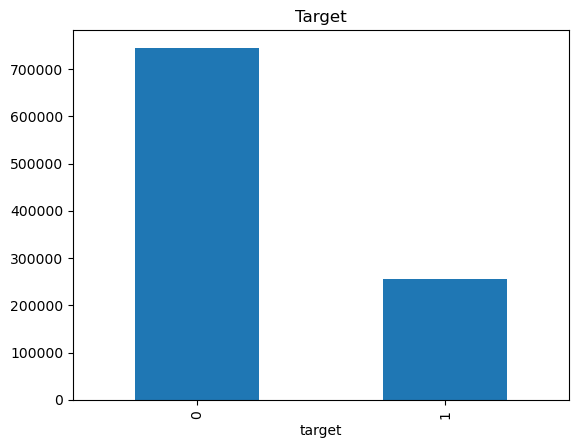

In [21]:
y.value_counts().plot.bar(title='Target')
plt.show()

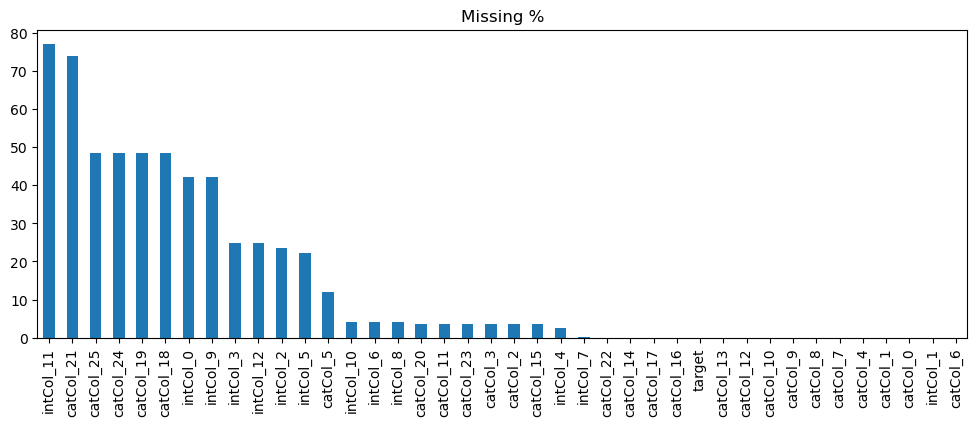

In [22]:
# Goal: see how much of each column is missing, so we know how aggressive
# the imputation step needs to be.

# Step 1: for every column, get the fraction of rows that are NaN.
# .isnull() gives a True/False mask; .mean() of booleans = fraction of Trues.
missing_fraction = df.isnull().mean()

# Step 2: convert fraction → percentage (easier to read on a chart).
missing_percent = missing_fraction * 100

# Step 3: sort biggest-first so the worst offenders are on the left of the bar chart.
missing_percent_sorted = missing_percent.sort_values(ascending=False)

# Step 4: plot.
missing_percent_sorted.plot.bar(figsize=(12, 4), title='Missing %')
plt.show()

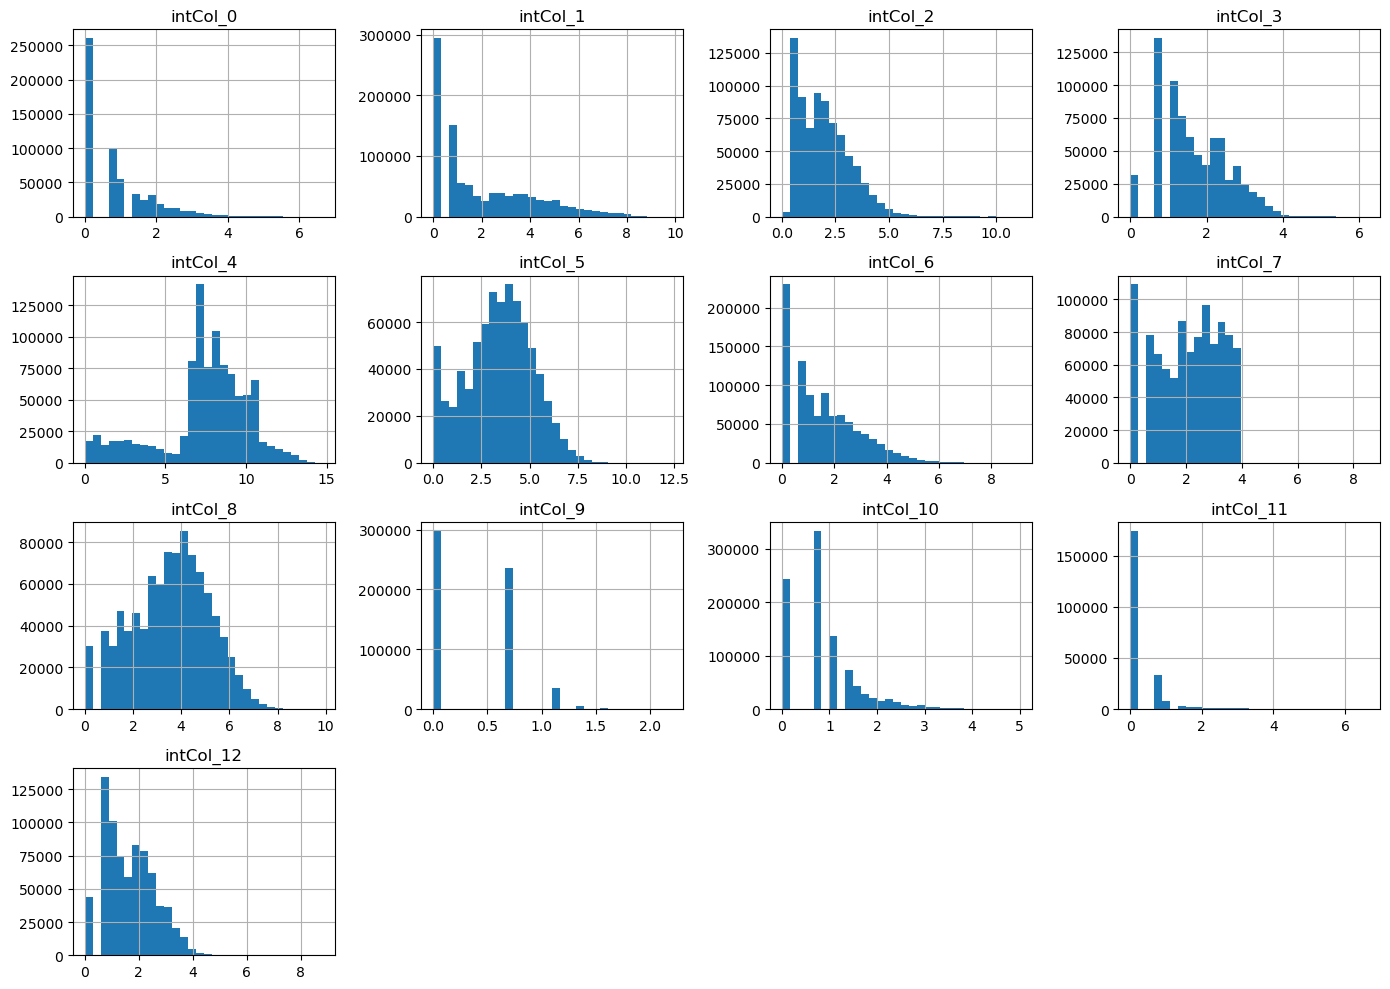

In [23]:
# Goal: look at the *shape* of each numeric feature so we can spot heavy skew.
# Many of these features are counts and span 0 → millions, which crushes a histogram —
# so we take a log to make them visually readable.

# Step 1: pull just the numeric columns out.
numerics = df[int_cols]

# Step 2: clip negatives to 0.
# Why: a couple of columns have small negative values (e.g. -1, -2 sentinel codes).
# log1p of a negative number is undefined, so we floor everything at 0 first.
numerics_nonneg = numerics.clip(lower=0)

# Step 3: apply log1p = log(1 + x).
# Why log1p instead of log? It handles 0 cleanly (log1p(0) = 0) instead of -inf.
numerics_logged = numerics_nonneg.apply(np.log1p)

# Step 4: histogram each column on its own subplot.
numerics_logged.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

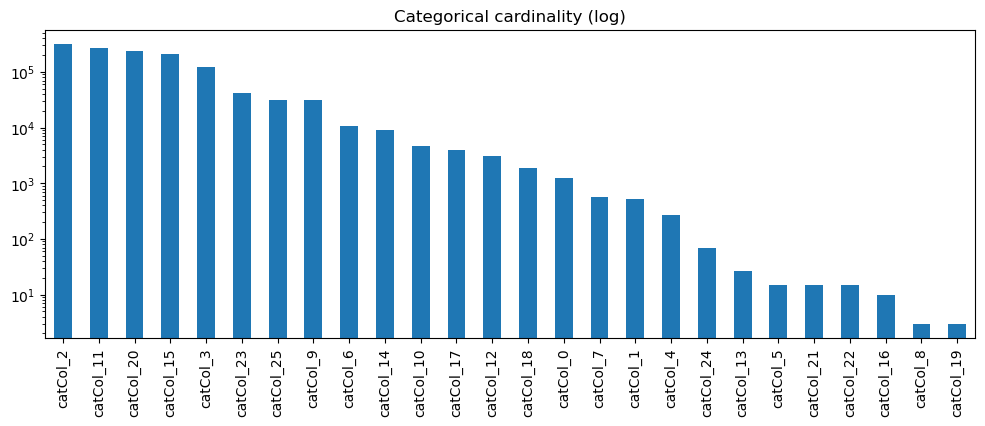

In [24]:
# Goal: for each categorical column, count how many *distinct* values it has.
# Why: this number directly decides which encoder we can use later.
#   - low cardinality (few uniques)  → one-hot is fine
#   - high cardinality (thousands+)  → one-hot would explode → need ordinal/target encoding

# Step 1: count unique values per categorical column.
cat_uniques = df[cat_cols].nunique()

# Step 2: sort biggest-first so the chart reads naturally.
cat_uniques_sorted = cat_uniques.sort_values(ascending=False)

# Step 3: plot on a log y-axis.
# Why logy=True: cardinalities span ~10 to >100,000 — on a linear axis the small
# columns disappear visually. Log scale lets us see them all at once.
cat_uniques_sorted.plot.bar(
    figsize=(12, 4),
    logy=True,
    title='Categorical cardinality (log)',
)
plt.show()

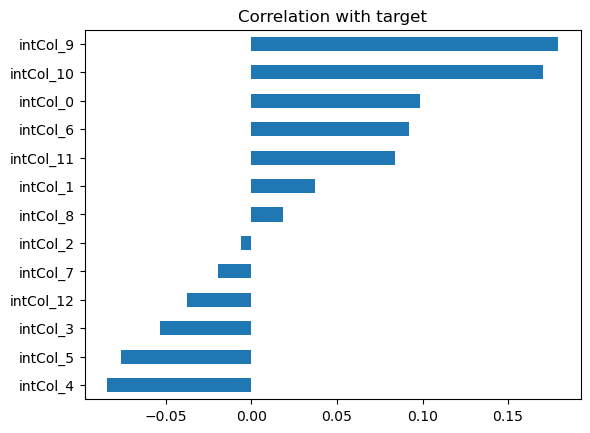

In [25]:
# Goal: cheap sanity check — does any single numeric feature correlate with the target?
# This is *not* a model; it just tells us the data has at least *some* signal.

# Step 1: build a smaller frame with just the numerics + the target.
# Why: corr() on the full frame would also include categorical columns we don't want here.
numerics_with_target = df[int_cols + ['target']]

# Step 2: full Pearson correlation matrix between every pair of those columns.
corr_matrix = numerics_with_target.corr()

# Step 3: pull out just the column we care about — correlation *with the target*.
corr_with_target = corr_matrix['target']

# Step 4: drop the self-correlation (target vs target = 1.0, not interesting).
corr_with_target = corr_with_target.drop('target')

# Step 5: sort so positive and negative correlations line up cleanly on the chart.
corr_with_target_sorted = corr_with_target.sort_values()

# Step 6: horizontal bar chart so the column names stay readable.
corr_with_target_sorted.plot.barh(title='Correlation with target')
plt.show()

## 2. Cleansing + Encoding + Scaling (one pipeline)

After EDA, my v1 guesses are:

- Some numerics have crazy max values (e.g. `intCol_4` reaches 2.5M). → **cap outliers** at the 1st/99th percentile.
- A lot of columns have heavy missingness. → **median impute** for numerics; for categoricals, treat missing as its own value (`'missing'`).
- Categoricals have huge cardinality (some > 100k unique values). → one-hot would explode. **OrdinalEncoder** is the simplest thing that just works (it gives each category an integer ID — fine for tree models).
- LR / KNN need scaled inputs. → **StandardScaler** on the numeric branch.

I want all of this in **one `ColumnTransformer`**. That way every model gets the same preprocessor, and when I plug it into a `Pipeline`, sklearn refits the preprocessor on each train fold automatically — so no leakage from val/test.

### Important caveat

**Every choice above is a guess.** The columns are hashed — we have no domain intuition that says "median imputation is right for this column" or "1/99 clipping is the right amount". So this section just gives us a **v1 to start from**. Sections 10–14 come back and try alternatives for each decision (encoder, scaler, imputer, outlier handling, model size) and let the val set tell us which choice actually works on this data.

In [26]:
# Goal: tame extreme values in the numeric columns.
# Some columns reached millions when the typical value is in the tens — those tails
# wreck linear models and skew tree splits.
#
# Strategy: "winsorize" — for each column, find the 1st and 99th percentile and
# clip every value that falls outside that range.
# This keeps the *shape* of the distribution but throws away the extreme tails.

for col in int_cols:
    # Step 1: compute the 1st and 99th percentile of this column.
    # df[col].quantile([0.01, 0.99]) returns a 2-element Series (one value per quantile).
    quantiles = df[col].quantile([0.01, 0.99])

    # Step 2: unpack into low / high cutoffs.
    low_cutoff  = quantiles.iloc[0]   # 1st percentile  → floor
    high_cutoff = quantiles.iloc[1]   # 99th percentile → ceiling

    # Step 3: clip the column in-place on X (our feature matrix).
    # Anything below low_cutoff becomes low_cutoff; anything above high_cutoff becomes high_cutoff.
    X[col] = X[col].clip(low_cutoff, high_cutoff)

# Quick sanity check: print the new min/max so we can see the tails are gone.
X[int_cols].describe().loc[['min', 'max']]

,intCol_0,intCol_1,intCol_2,intCol_3,intCol_4,intCol_5,intCol_6,intCol_7,intCol_8,intCol_9,intCol_10,intCol_11,intCol_12
min,0.0,-1.0,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,37.0,1986.0,170.0,39.0,336419.11,1289.0,187.0,48.0,965.0,3.0,23.0,19.0,44.0


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp',   SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), int_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('oe',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), cat_cols),
])

## 3. Feature Importance

Just curious which features actually matter. I fit a quick random forest (small, capped depth, on a 100k sample so it's fast) and look at its built-in `feature_importances_`. It's not a final answer — just a sanity check that the model is picking up signal from a reasonable mix of features rather than relying on one weird column.

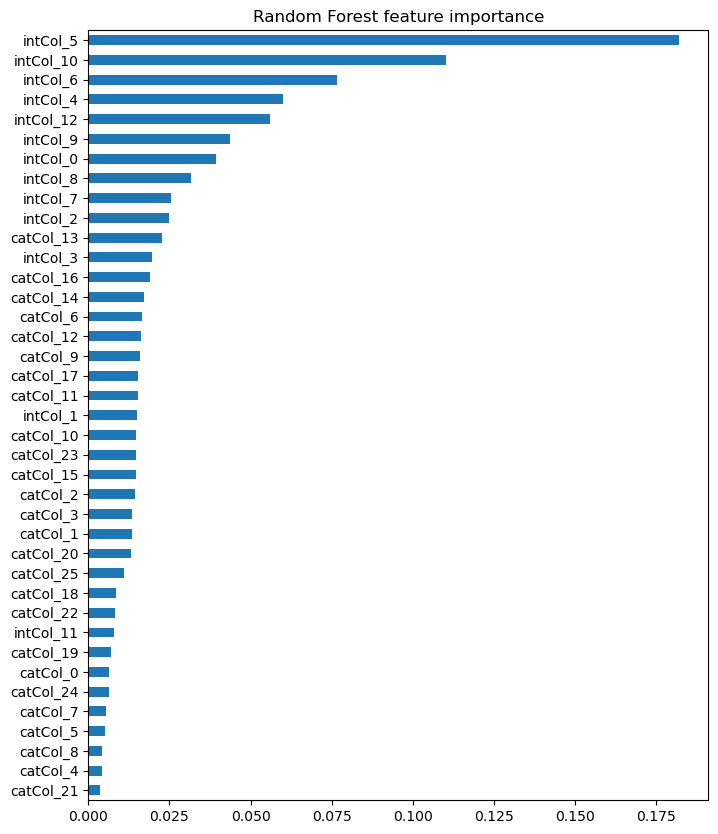

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Goal: a quick "which features matter?" check using a small random forest.
# This is *not* the model we'll ship — it's a 30-second diagnostic.

# Step 1: build a pipeline = preprocessor + small random forest.
# Why a Pipeline: it ties preprocessing and the model together so the same
# preprocessing is applied consistently when we call fit / predict.
fs_pipe = Pipeline([
    ('prep', preprocessor),                       # imputes / scales / encodes
    ('rf',   RandomForestClassifier(
        n_estimators=100,    # 100 trees — enough to be stable, cheap to fit
        max_depth=10,        # capped depth so it stays fast and doesn't overfit hard
        n_jobs=-1,           # use all CPU cores
        random_state=42,     # reproducible
    )),
])

# Step 2: take a 100k-row sample.
# Why: fitting on the full 1M rows is unnecessary for a sanity check — the
# importance ranking is already stable on a sample this size.
sample_X = X.sample(100_000, random_state=42)
sample_y = y.loc[sample_X.index]   # keep labels aligned with the sampled rows

# Step 3: fit the pipeline.
fs_pipe.fit(sample_X, sample_y)

# Step 4: pull out the random forest's built-in feature importances.
# The order matches the order columns came out of the preprocessor:
#   numerics first, then categoricals.
rf_model = fs_pipe.named_steps['rf']
importances = rf_model.feature_importances_

# Step 5: wrap in a Series with the right names so the chart is readable.
imp = pd.Series(importances, index=int_cols + cat_cols)

# Step 6: sort + plot horizontally so column names stay legible.
imp_sorted = imp.sort_values()
imp_sorted.plot.barh(figsize=(8, 10), title='Random Forest feature importance')
plt.show()

## 4. Stratified Train / Val / Test Split (60 / 20 / 20)

Three sets because:
- **Train** is what I fit on.
- **Val** is what I use to compare models / pick hyperparameters / decide a cutoff. Looking at val numbers and changing my approach is fine — that's why it exists.
- **Test** I touch *exactly once*, at the very end. If I use it for anything before that, my final number gets optimistically biased.

`stratify=y` keeps the same positive rate (~25%) in every split. With imbalanced classes, an unstratified split can land you with way too few positives in val or test by random chance.

In [29]:
from sklearn.model_selection import train_test_split

# 1. Split off test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 2. Split remainder into train (75%) and val (25%) — i.e. 60/20 of the full data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print(f'Train: {len(X_train):>7,}  positive rate {y_train.mean():.4f}')
print(f'Val:   {len(X_val):>7,}  positive rate {y_val.mean():.4f}')
print(f'Test:  {len(X_test):>7,}  positive rate {y_test.mean():.4f}')

Train: 600,000  positive rate 0.2549
Val:   200,000  positive rate 0.2550
Test:  200,000  positive rate 0.2550


## 5. Compare Models on Validation Set

I want to try a small variety of models so I'm not biased by one family:

- **LR** — linear, the classic baseline.
- **NB** — fast, probabilistic. Bad assumptions but a useful sanity check.
- **KNN** — distance-based, completely different paradigm.
- **GBM** (HistGradientBoosting) — gradient-boosted trees, usually the strongest on tabular data.

Fit each one on train, then score on val with the **full metric set**: accuracy, precision, recall, F1, ROC-AUC, and a confusion matrix. ROC-AUC alone tells us how well a model *ranks* probabilities, but it hides what happens at the 0.5 cutoff — two models with similar AUC can have wildly different precision/recall trade-offs. Looking at all five metrics + the confusion matrix gives us a fuller picture before committing to a winner.

We still pick the winner on **ROC-AUC** because it's threshold-independent (and section 8 will tune the cutoff separately), but now we can also see *why* it won and what its precision/recall look like out of the box. KNN is fit on a 50k sample because it's slow on 600k.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

# Goal: pick a winner. Try 4 different model families on the *same* val set
# and look at the full metric picture — not just ROC-AUC — before committing.
#
# We compute: accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.
# Why all of them: ROC-AUC tells us about *ranking* quality, but at the 0.5 cutoff
# two models with similar AUC can have very different precision/recall behavior.
# Seeing all five (+ the confusion matrix) shows us *what kind* of mistakes each
# model makes, not just how well it ranks.
#
# The winner is still chosen on ROC-AUC because it's threshold-independent and
# section 8 will tune the cutoff separately.

# Step 1: define each model with its name.
models = {
    'NB':  GaussianNB(),                              # cheap probabilistic baseline
    'KNN': KNeighborsClassifier(n_neighbors=25, n_jobs=-1),  # distance-based, totally different paradigm
    'GBM': HistGradientBoostingClassifier(random_state=42),  # gradient-boosted trees, usually wins on tabular
}

# Step 2: KNN special-case.
# KNN scales as O(N²) at predict time — fitting on 600k rows would take forever.
# So we sample 50k rows for KNN only. The other models train on the full train set.
knn_sample_X = X_train.sample(50_000, random_state=42)
knn_sample_y = y_train.loc[knn_sample_X.index]

# Step 3: loop over the models, fit each one, score on val, store every metric.
val_results = {}
val_confusions = {}
for name, model in models.items():

    # Wrap the model in a pipeline so it gets the preprocessing applied.
    pipe = Pipeline([
        ('prep', preprocessor),
        ('clf',  model),
    ])

    # Fit — KNN on the sample, others on the full training set.
    if name == 'KNN':
        pipe.fit(knn_sample_X, knn_sample_y)
    else:
        pipe.fit(X_train, y_train)

    # Probability of the positive class for ROC-AUC.
    val_proba = pipe.predict_proba(X_val)[:, 1]
    # Hard 0/1 prediction at the default 0.5 cutoff for the threshold-dependent metrics.
    val_pred  = (val_proba >= 0.25).astype(int)

    val_results[name] = {
        'accuracy':  accuracy_score(y_val, val_pred),
        'precision': precision_score(y_val, val_pred),
        'recall':    recall_score(y_val, val_pred),
        'f1':        f1_score(y_val, val_pred),
        'roc_auc':   roc_auc_score(y_val, val_proba),
    }
    val_confusions[name] = confusion_matrix(y_val, val_pred)

    # Print a one-line summary as each model finishes so we don't wait silently.
    r = val_results[name]
    print(
        f"{name:>3s}: "
        f"Acc={r['accuracy']:.4f}  "
        f"Prec={r['precision']:.4f}  "
        f"Rec={r['recall']:.4f}  "
        f"F1={r['f1']:.4f}  "
        f"AUC={r['roc_auc']:.4f}"
    )

# Step 4: confusion matrices — one per model, so we can see the failure pattern.
print('\nConfusion matrices (rows = actual, cols = predicted; class order: [no click, click]):')
for name, cm in val_confusions.items():
    print(f'\n{name}:')
    print(cm)

# Step 5: tidy comparison table, sorted by ROC-AUC.
results_df = pd.DataFrame(val_results).T.sort_values('roc_auc', ascending=False)
print('\nComparison table (sorted by ROC-AUC):')
print(results_df.round(4))

# Step 6: pick the winner on ROC-AUC (threshold-independent ranking quality).
best_name = results_df.index[0]
print(f'\nBest model on val (by ROC-AUC): {best_name} ({results_df.loc[best_name, "roc_auc"]:.4f})')
results_df

 NB: Acc=0.6977  Prec=0.4151  Rec=0.4536  F1=0.4335  AUC=0.6727
KNN: Acc=0.5158  Prec=0.2912  Rec=0.6272  F1=0.3978  AUC=0.5790
GBM: Acc=0.6962  Prec=0.4382  Rec=0.6802  F1=0.5330  AUC=0.7594

Confusion matrices (rows = actual, cols = predicted; class order: [no click, click]):

NB:
[[116417  32593]
 [ 27863  23127]]

KNN:
[[71183 77827]
 [19011 31979]]

GBM:
[[104549  44461]
 [ 16309  34681]]

Comparison table (sorted by ROC-AUC):
     accuracy  precision  recall      f1  roc_auc
GBM    0.6962     0.4382  0.6802  0.5330   0.7594
NB     0.6977     0.4151  0.4536  0.4335   0.6727
KNN    0.5158     0.2912  0.6272  0.3978   0.5790

Best model on val (by ROC-AUC): GBM (0.7594)


,accuracy,precision,recall,f1,roc_auc
GBM,0.69615,0.438212,0.680153,0.533013,0.759440
NB,0.69772,0.415057,0.453560,0.433455,0.672697
KNN,0.51581,0.291232,0.627162,0.397759,0.579037


## 6. Final Evaluation on Test Set

GBM won on val. Now the final move:

1. **Refit on train + val combined** — there's no reason to throw away val data once I'm done using it for selection. More training data = slightly better final model.
2. **Predict on the test set, once.** Whatever number comes out is my real estimate of how the model would perform in the wild.

I report accuracy, precision, recall, F1, ROC-AUC, plus a confusion matrix. Accuracy alone is misleading on imbalanced data (always-predict-0 already gets ~75%) — that's why precision/recall and ROC-AUC matter more here.

In [31]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

# Goal: final, honest evaluation of the chosen model (GBM) on the test set.
# Until now, test has been completely untouched. We touch it once.

# Step 1: combine train + val into a bigger training set.
# Why: val has done its job (model selection). Throwing it away would waste data —
# more training data = slightly better final model. The test set still stays held out.
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# Step 2: build a fresh pipeline with the winning model and refit it.
final_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  HistGradientBoostingClassifier(random_state=42)),
])
final_pipe.fit(X_trainval, y_trainval)

# Step 3: predict probabilities on the test set.
proba = final_pipe.predict_proba(X_test)[:, 1]   # P(click) for every test row

# Step 4: convert probabilities to a hard 0/1 prediction using a 0.5 cutoff.
# (We'll revisit this cutoff in section 8 — it's not a great default for imbalanced data.)
pred = (proba >= 0.5).astype(int)

# Step 5: print the standard set of metrics.
# Why so many: accuracy alone is misleading on imbalanced data
# (always-predict-0 already gets ~75%). Precision/recall/F1/AUC tell the real story.
print(f'Accuracy : {accuracy_score(y_test, pred):.4f}')
print(f'Precision: {precision_score(y_test, pred):.4f}')   # of predicted clicks, how many were real?
print(f'Recall   : {recall_score(y_test, pred):.4f}')      # of real clicks, how many did we catch?
print(f'F1       : {f1_score(y_test, pred):.4f}')          # harmonic mean of precision & recall
print(f'ROC AUC  : {roc_auc_score(y_test, proba):.4f}')    # threshold-independent ranking quality

# Step 6: confusion matrix + per-class report for a richer view.
print('\nConfusion matrix:')
print(confusion_matrix(y_test, pred))
print('\n', classification_report(y_test, pred, target_names=['no click', 'click']))

Accuracy : 0.7754
Precision: 0.6640
Recall   : 0.2410
F1       : 0.3536
ROC AUC  : 0.7602

Confusion matrix:
[[142792   6218]
 [ 38703  12287]]

               precision    recall  f1-score   support

    no click       0.79      0.96      0.86    149010
       click       0.66      0.24      0.35     50990

    accuracy                           0.78    200000
   macro avg       0.73      0.60      0.61    200000
weighted avg       0.76      0.78      0.73    200000



## 7. Handling Class Imbalance with Resampling

The test recall came out around **0.24** — meaning the model misses 3 out of every 4 actual clicks. That's because:
- The classes are imbalanced (~25% positive).
- The default 0.5 cutoff makes the model conservative — it only says "click" when it's very sure.

One way to fix this is to **rebalance the training set** so the model sees the minority class more often:

- **ROS (RandomOverSampler)** — duplicate random minority examples until the classes are balanced. Cheap, sometimes overfits.
- **RUS (RandomUnderSampler)** — drop random majority examples instead. Even cheaper but throws away data.
- **SMOTE** — synthesize new minority examples by interpolating between real ones and their nearest neighbors. Smarter than ROS but slow, and only really makes sense when the numeric features are meaningful — it can produce nonsense for things like ordinal-encoded categorical IDs.
- **SMOTETomek** — SMOTE first, then remove "Tomek links" (pairs of opposite-class neighbors that are too close, i.e. fuzzy boundaries) for a cleaner decision surface.

The sampler only fires inside `pipe.fit()` — val/test are evaluated on the real distribution, which is what we want.

In [32]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline   # imblearn version supports samplers as steps

# Goal: see whether resampling the training data improves recall.
# Critical detail: resampling is a *training-only* trick. We never touch val/test,
# because we want our evaluation to reflect the real-world class distribution.

# Step 1: define the techniques to compare.
# 'None' is the baseline — same model, same data, no resampling.
techniques = {
    'None (baseline)': None,
    'ROS':        RandomOverSampler(random_state=47),    # duplicate minority rows
    'RUS':        RandomUnderSampler(random_state=47),   # drop majority rows
    'SMOTE':      SMOTE(random_state=47),                # synthesize new minority rows
    'SMOTETomek': SMOTETomek(random_state=47),           # SMOTE + clean fuzzy boundaries
}

# Step 2: shrink the training set for this comparison.
# Why: SMOTE/SMOTETomek do nearest-neighbor work — slow on 600k rows.
# 100k is plenty to compare techniques relative to each other.
imb_train_X = X_train.sample(100_000, random_state=42)
imb_train_y = y_train.loc[imb_train_X.index]

# Step 3: loop through each technique, build a pipeline, fit, score on val.
imb_results = {}
for name, sampler in techniques.items():

    # Build the pipeline step-by-step.
    # imblearn's Pipeline knows that samplers should only run during .fit() —
    # so val/test don't get resampled at predict time. That's the whole point.
    steps = [('prep', preprocessor)]                # always preprocess first

    if sampler is not None:                          # baseline has no sampler
        steps.append(('sampler', sampler))

    steps.append(('clf', HistGradientBoostingClassifier(random_state=42)))
    pipe = ImbPipeline(steps)

    # Fit (resampling happens here, inside .fit).
    pipe.fit(imb_train_X, imb_train_y)

    # Predict on val. The val set is the *real* distribution — that's what we report on.
    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pred  = (val_proba >= 0.5).astype(int)

    # Compute every metric we care about and stash it.
    imb_results[name] = {
        'accuracy':  accuracy_score(y_val, val_pred),
        'precision': precision_score(y_val, val_pred),
        'recall':    recall_score(y_val, val_pred),
        'f1':        f1_score(y_val, val_pred),
        'roc_auc':   roc_auc_score(y_val, val_proba),
    }

    # Pretty-print the row immediately so we don't have to wait for the loop to finish.
    r = imb_results[name]
    print(
        f"{name:>18s}: "
        f"F1={r['f1']:.4f}  "
        f"Recall={r['recall']:.4f}  "
        f"Precision={r['precision']:.4f}  "
        f"AUC={r['roc_auc']:.4f}"
    )

# Step 4: sort the table by F1 so the best technique is on top.
results_df = pd.DataFrame(imb_results).T
results_df_sorted = results_df.sort_values('f1', ascending=False)
results_df_sorted

   None (baseline): F1=0.3188  Recall=0.2117  Precision=0.6456  AUC=0.7462
               ROS: F1=0.5126  Recall=0.5998  Precision=0.4476  AUC=0.7413
               RUS: F1=0.5174  Recall=0.6374  Precision=0.4354  AUC=0.7428
             SMOTE: F1=0.3613  Recall=0.2557  Precision=0.6153  AUC=0.7454
        SMOTETomek: F1=0.3394  Recall=0.2327  Precision=0.6265  AUC=0.7445


,accuracy,precision,recall,f1,roc_auc
RUS,0.696830,0.435405,0.637439,0.517399,0.742772
ROS,0.709230,0.447581,0.599823,0.512638,0.741309
SMOTE,0.769475,0.615250,0.255717,0.361276,0.745408
SMOTETomek,0.769015,0.626538,0.232712,0.339373,0.744516
None (baseline),0.769385,0.645553,0.211669,0.318805,0.746154
